In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Install required libraries
!pip install -q timm

# Copy datasets from Drive
!rm -rf /content/binary_dataset
!rm -rf /content/multiclass_dataset

!cp -r "/content/drive/MyDrive/EarProject/binary_dataset" /content/
!cp -r "/content/drive/MyDrive/EarProject/multiclass_dataset" /content/

# Import Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

print("Setup Complete")
print("Binary dataset exists:", os.path.exists("/content/binary_dataset"))
print("Multiclass dataset exists:", os.path.exists("/content/multiclass_dataset"))


Mounted at /content/drive
Device: cuda
Setup Complete
Binary dataset exists: True
Multiclass dataset exists: True


## **Swin Transformer - Binary Classification**

In [ ]:
from PIL import Image
import os

def remove_corrupted_images(folder):
    removed = 0
    for root, dirs, files in os.walk(folder):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path)
                img.verify()
            except:
                print("Removing corrupted:", path)
                os.remove(path)
                removed += 1
    print("Total removed:", removed)

In [ ]:
remove_corrupted_images("/content/binary_dataset")

Removing corrupted: /content/binary_dataset/train/Abnormal/aom-366-_jpg.rf.26b5e09a41dd09a5d0c72e82018b6a57.jpg
Total removed: 1


In [ ]:
train_dir = "/content/binary_dataset/train"
val_dir = "/content/binary_dataset/valid"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)

print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

Classes: ['Abnormal', 'Normal']
Train size: 2337
Validation size: 292


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 74
Validation batches: 10


In [ ]:
import timm
import torch.nn as nn

model_swin_binary = timm.create_model(
    'swin_tiny_patch4_window7_224',
    pretrained=True,
    num_classes=2
)

model_swin_binary = model_swin_binary.to(device)

print("Swin-Tiny Binary model loaded")

Swin-Tiny Binary model loaded


In [ ]:
for param in model_swin_binary.parameters():
    param.requires_grad = False

for param in model_swin_binary.head.parameters():
    param.requires_grad = True

In [ ]:
criterion_swin = nn.CrossEntropyLoss()

optimizer_swin = torch.optim.Adam(
    model_swin_binary.head.parameters(),
    lr=0.0001
)

print("Loss and Optimizer ready")

Loss and Optimizer ready


In [ ]:
num_epochs = 10
best_val_acc = 0

for epoch in range(num_epochs):

    # TRAINING
    model_swin_binary.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_swin.zero_grad()
        outputs = model_swin_binary(images)
        loss = criterion_swin(outputs, labels)
        loss.backward()
        optimizer_swin.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train

    # VALIDATION
    model_swin_binary.eval()
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_swin_binary(images)
            _, predicted = torch.max(outputs, 1)

            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_accuracy = 100 * correct_val / total_val

    # Save best model
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model_swin_binary.state_dict(),
                   "/content/drive/MyDrive/EarProject/models/swin_binary_best.pth")

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"- Train Loss: {train_loss:.4f} "
          f"- Train Acc: {train_accuracy:.2f}% "
          f"- Val Acc: {val_accuracy:.2f}%")

print("Best Validation Accuracy:", best_val_acc)

Epoch [1/10] - Train Loss: 0.1300 - Train Acc: 95.93% - Val Acc: 93.84%
Epoch [2/10] - Train Loss: 0.1254 - Train Acc: 95.68% - Val Acc: 94.52%
Epoch [3/10] - Train Loss: 0.1231 - Train Acc: 96.28% - Val Acc: 93.84%
Epoch [4/10] - Train Loss: 0.1222 - Train Acc: 96.06% - Val Acc: 94.86%
Epoch [5/10] - Train Loss: 0.1235 - Train Acc: 95.81% - Val Acc: 94.86%
Epoch [6/10] - Train Loss: 0.1133 - Train Acc: 97.00% - Val Acc: 94.86%
Epoch [7/10] - Train Loss: 0.1083 - Train Acc: 96.79% - Val Acc: 94.86%
Epoch [8/10] - Train Loss: 0.1153 - Train Acc: 96.32% - Val Acc: 94.86%
Epoch [9/10] - Train Loss: 0.1132 - Train Acc: 96.45% - Val Acc: 95.89%
Epoch [10/10] - Train Loss: 0.1128 - Train Acc: 96.79% - Val Acc: 95.55%
Best Validation Accuracy: 95.89041095890411


In [ ]:
# Test Dataset
test_dir = "/content/binary_dataset/test"
test_dataset = datasets.ImageFolder(test_dir, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model_swin_binary.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_swin_binary(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print("Total Test Samples:", total)
print("Correct Predictions:", correct)
print("Test Accuracy: {:.2f}%".format(test_accuracy))

Total Test Samples: 292
Correct Predictions: 284
Test Accuracy: 97.26%


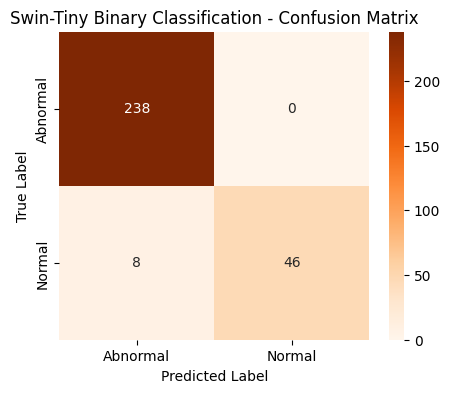


Classification Report:

              precision    recall  f1-score   support

    Abnormal       0.97      1.00      0.98       238
      Normal       1.00      0.85      0.92        54

    accuracy                           0.97       292
   macro avg       0.98      0.93      0.95       292
weighted avg       0.97      0.97      0.97       292



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

all_preds = []
all_labels = []

model_swin_binary.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_swin_binary(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Oranges",
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Swin-Tiny Binary Classification - Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds,
                            target_names=test_dataset.classes))

## **Swin Transformer - Multiclass Classification**

In [ ]:
!rm -rf /content/ear_dataset
!cp -r "/content/drive/MyDrive/Ear Diseases/Dataset/extracted" /content/ear_dataset
print("Original ear_dataset restored")

Original ear_dataset restored


In [ ]:
import json

ann_path = "/content/ear_dataset/train/_annotations.coco.json"
new_ann_path = "/content/ear_dataset/train/_annotations_filtered.coco.json"

with open(ann_path) as f:
    data = json.load(f)

filtered_categories = [c for c in data['categories'] if c['name'] != 'ear_conditions-zL5Z']
data['categories'] = filtered_categories

valid_ids = [c['id'] for c in filtered_categories]
data['annotations'] = [a for a in data['annotations'] if a['category_id'] in valid_ids]

with open(new_ann_path, "w") as f:
    json.dump(data, f)

print("Filtered annotation recreated")

Filtered annotation recreated


In [ ]:
import os, json, shutil
from collections import defaultdict

base_dir = "/content/ear_dataset"
multi_dir = "/content/multiclass_dataset"

!rm -rf /content/multiclass_dataset

splits = ["train", "valid", "test"]

disease_map = {
    "aom": "AOM",
    "ci": "CI",
    "com": "COM",
    "mys": "MYS"
}

for split in splits:
    for d in disease_map.values():
        os.makedirs(f"{multi_dir}/{split}/{d}", exist_ok=True)

    ann_path = f"{base_dir}/{split}/_annotations.coco.json"

    with open(ann_path) as f:
        data = json.load(f)

    cat_map = {c['id']: c['name'] for c in data['categories']}
    img_map = {img['id']: img['file_name'] for img in data['images']}

    img_labels = defaultdict(set)

    for ann in data['annotations']:
        label = cat_map[ann['category_id']]

        if label in disease_map:
            img_labels[ann['image_id']].add(label)

    for img_id, labels in img_labels.items():
        file_name = img_map[img_id]
        src = f"{base_dir}/{split}/{file_name}"

        if len(labels) == 1:
            disease = list(labels)[0]
            dst = f"{multi_dir}/{split}/{disease_map[disease]}/{file_name}"
            if os.path.exists(src):
                shutil.copy(src, dst)

print("Multiclass dataset recreated successfully!")

Multiclass dataset recreated successfully!


In [ ]:
remove_corrupted_images("/content/multiclass_dataset")

Removing corrupted: /content/multiclass_dataset/train/AOM/aom-366-_jpg.rf.26b5e09a41dd09a5d0c72e82018b6a57.jpg
Total removed: 1


In [ ]:
train_dir_multi = "/content/multiclass_dataset/train"
val_dir_multi = "/content/multiclass_dataset/valid"

from torchvision import datasets
from torch.utils.data import DataLoader

train_dataset_multi = datasets.ImageFolder(train_dir_multi, transform=train_transforms)
val_dataset_multi = datasets.ImageFolder(val_dir_multi, transform=val_transforms)

print("Classes:", train_dataset_multi.classes)
print("Train size:", len(train_dataset_multi))
print("Validation size:", len(val_dataset_multi))

Classes: ['AOM', 'CI', 'COM', 'MYS']
Train size: 1868
Validation size: 215


In [ ]:
train_loader_multi = DataLoader(train_dataset_multi, batch_size=32, shuffle=True, num_workers=2)
val_loader_multi = DataLoader(val_dataset_multi, batch_size=32, shuffle=False, num_workers=2)

print("Train batches:", len(train_loader_multi))
print("Validation batches:", len(val_loader_multi))

Train batches: 59
Validation batches: 7


In [ ]:
import timm
import torch.nn as nn

model_swin_multi = timm.create_model(
    'swin_tiny_patch4_window7_224',
    pretrained=True,
    num_classes=4
)

model_swin_multi = model_swin_multi.to(device)

print("Swin-Tiny Multi-class model ready")

Swin-Tiny Multi-class model ready


In [ ]:
for param in model_swin_multi.parameters():
    param.requires_grad = False

for param in model_swin_multi.head.parameters():
    param.requires_grad = True


In [ ]:
criterion_swin_multi = nn.CrossEntropyLoss()

optimizer_swin_multi = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_swin_multi.parameters()),
    lr=0.0001
)

print("Loss and Optimizer ready")

Loss and Optimizer ready


In [ ]:
num_epochs = 10
best_val_acc = 0

for epoch in range(num_epochs):

    # TRAINING
    model_swin_multi.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader_multi:
        images, labels = images.to(device), labels.to(device)

        optimizer_swin_multi.zero_grad()
        outputs = model_swin_multi(images)
        loss = criterion_swin_multi(outputs, labels)
        loss.backward()
        optimizer_swin_multi.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader_multi)
    train_accuracy = 100 * correct_train / total_train

    # VALIDATION
    model_swin_multi.eval()
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader_multi:
            images, labels = images.to(device), labels.to(device)
            outputs = model_swin_multi(images)
            _, predicted = torch.max(outputs, 1)

            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_accuracy = 100 * correct_val / total_val

    # Save best model
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model_swin_multi.state_dict(),
                   "/content/drive/MyDrive/EarProject/models/swin_multiclass_best.pth")

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"- Train Loss: {train_loss:.4f} "
          f"- Train Acc: {train_accuracy:.2f}% "
          f"- Val Acc: {val_accuracy:.2f}%")

print("Best Validation Accuracy:", best_val_acc)

Epoch [1/10] - Train Loss: 0.1767 - Train Acc: 98.07% - Val Acc: 94.88%
Epoch [2/10] - Train Loss: 0.1635 - Train Acc: 98.23% - Val Acc: 95.35%
Epoch [3/10] - Train Loss: 0.1502 - Train Acc: 98.34% - Val Acc: 95.81%
Epoch [4/10] - Train Loss: 0.1380 - Train Acc: 98.61% - Val Acc: 95.81%
Epoch [5/10] - Train Loss: 0.1254 - Train Acc: 98.93% - Val Acc: 95.81%
Epoch [6/10] - Train Loss: 0.1198 - Train Acc: 98.77% - Val Acc: 96.28%
Epoch [7/10] - Train Loss: 0.1124 - Train Acc: 98.82% - Val Acc: 96.74%
Epoch [8/10] - Train Loss: 0.1051 - Train Acc: 98.82% - Val Acc: 96.28%
Epoch [9/10] - Train Loss: 0.1052 - Train Acc: 98.72% - Val Acc: 96.74%
Epoch [10/10] - Train Loss: 0.0997 - Train Acc: 98.66% - Val Acc: 96.74%
Best Validation Accuracy: 96.74418604651163


In [ ]:
# Test Dataset
test_dir_multi = "/content/multiclass_dataset/test"
test_dataset_multi = datasets.ImageFolder(test_dir_multi, transform=val_transforms)
test_loader_multi = DataLoader(test_dataset_multi, batch_size=32, shuffle=False)

model_swin_multi.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader_multi:
        images, labels = images.to(device), labels.to(device)
        outputs = model_swin_multi(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print("Total Test Samples:", total)
print("Correct Predictions:", correct)
print("Test Accuracy: {:.2f}%".format(test_accuracy))

Total Test Samples: 238
Correct Predictions: 233
Test Accuracy: 97.90%


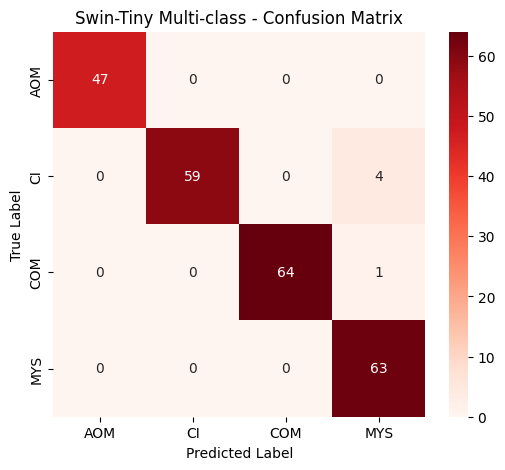


Classification Report:

              precision    recall  f1-score   support

         AOM       1.00      1.00      1.00        47
          CI       1.00      0.94      0.97        63
         COM       1.00      0.98      0.99        65
         MYS       0.93      1.00      0.96        63

    accuracy                           0.98       238
   macro avg       0.98      0.98      0.98       238
weighted avg       0.98      0.98      0.98       238



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

all_preds = []
all_labels = []

model_swin_multi.eval()

with torch.no_grad():
    for images, labels in test_loader_multi:
        images = images.to(device)
        outputs = model_swin_multi(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Reds",
            xticklabels=test_dataset_multi.classes,
            yticklabels=test_dataset_multi.classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Swin-Tiny Multi-class - Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds,
                            target_names=test_dataset_multi.classes))

In [ ]:
import timm
import torch.nn as nn

binary_model_swin = timm.create_model(
    'swin_tiny_patch4_window7_224',
    pretrained=False,
    num_classes=2
)

binary_model_swin.load_state_dict(torch.load(
    "/content/drive/MyDrive/EarProject/models/swin_binary_best.pth"
))

binary_model_swin = binary_model_swin.to(device)
binary_model_swin.eval()


multi_model_swin = timm.create_model(
    'swin_tiny_patch4_window7_224',
    pretrained=False,
    num_classes=4
)

multi_model_swin.load_state_dict(torch.load(
    "/content/drive/MyDrive/EarProject/models/swin_multiclass_best.pth"
))

multi_model_swin = multi_model_swin.to(device)
multi_model_swin.eval()

print("Swin Binary and Multi-class models loaded successfully!")

Swin Binary and Multi-class models loaded successfully!


In [ ]:
disease_full_names = {
    "AOM": "Acute Otitis Media (AOM)",
    "CI": "Chronic Inflammation (CI)",
    "COM": "Chronic Otitis Media (COM)",
    "MYS": "Myringitis (MYS)"
}

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F

def predict_ear_image(image_path):

    image = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(4,4))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Input Ear Image")
    plt.show()

    img_tensor = val_transforms(image).unsqueeze(0).to(device)

    with torch.no_grad():
        binary_output = binary_model_swin(img_tensor)
        binary_probs = F.softmax(binary_output, dim=1)
        binary_conf, binary_pred = torch.max(binary_probs, 1)

    binary_class = ["Abnormal", "Normal"][binary_pred.item()]
    binary_confidence = binary_conf.item() * 100

    print("Binary Prediction:", binary_class)
    print("Confidence: {:.2f}%".format(binary_confidence))

    if binary_class == "Normal":
        print("\nEar looks Normal. No disease detected.")
        return

    with torch.no_grad():
        multi_output = multi_model_swin(img_tensor)
        multi_probs = F.softmax(multi_output, dim=1)
        multi_conf, multi_pred = torch.max(multi_probs, 1)

    disease_class = train_dataset_multi.classes[multi_pred.item()]
    disease_name = disease_full_names[disease_class]
    disease_confidence = multi_conf.item() * 100

    print("\nDisease Type:", disease_name)
    print("Disease Confidence: {:.2f}%".format(disease_confidence))

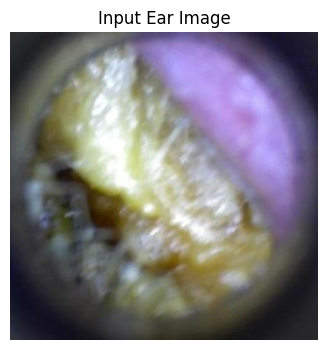

Binary Prediction: Abnormal
Confidence: 99.90%

Disease Type: Chronic Inflammation (CI)
Disease Confidence: 88.81%


In [ ]:
predict_ear_image("/content/drive/MyDrive/Ear Diseases/Dataset/extracted/test/ci-592-_jpg.rf.1551331e74950ab617f5fb4a3b90fb01.jpg")

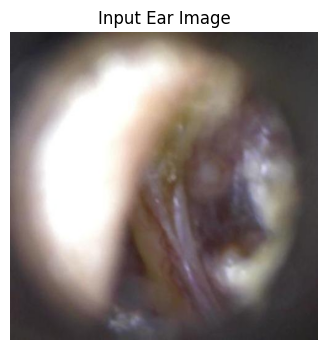

Binary Prediction: Abnormal
Confidence: 99.91%

Disease Type: Chronic Otitis Media (COM)
Disease Confidence: 91.32%


In [ ]:
predict_ear_image("/content/ear_dataset/test/com-32-_jpg.rf.43dc381c54f3c9c5dff0b01288afb2e0.jpg")

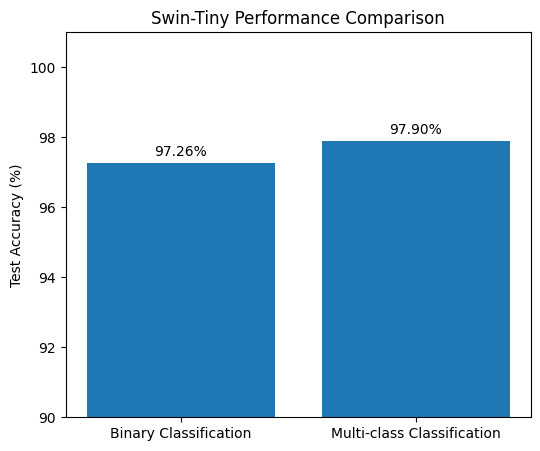

In [ ]:
import matplotlib.pyplot as plt

binary_accuracy = 97.26
multiclass_accuracy = 97.90

models = ['Binary Classification', 'Multi-class Classification']
accuracies = [binary_accuracy, multiclass_accuracy]

plt.figure(figsize=(6,5))

bars = plt.bar(models, accuracies)

plt.ylim(90, 101)
plt.ylabel("Test Accuracy (%)")
plt.title("Swin-Tiny Performance Comparison")

for i in range(len(accuracies)):
    plt.text(i, accuracies[i] + 0.2,
             f"{accuracies[i]:.2f}%",
             ha='center')

plt.show()

## **COMPARISON OF FOUR MODELS**

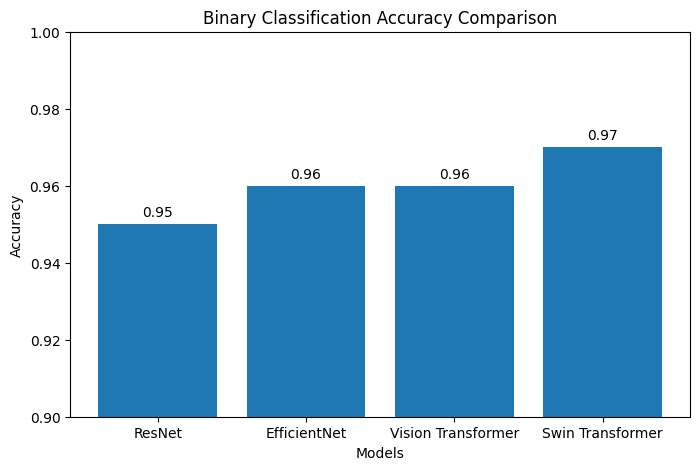

In [ ]:
import matplotlib.pyplot as plt

models = ['ResNet', 'EfficientNet', 'Vision Transformer', 'Swin Transformer']
binary_accuracy = [0.95, 0.96, 0.96, 0.97]

plt.figure(figsize=(8,5))
bars = plt.bar(models, binary_accuracy)

plt.title("Binary Classification Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0.90, 1.00)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.002, f"{y:.2f}",
             ha='center')

plt.show()

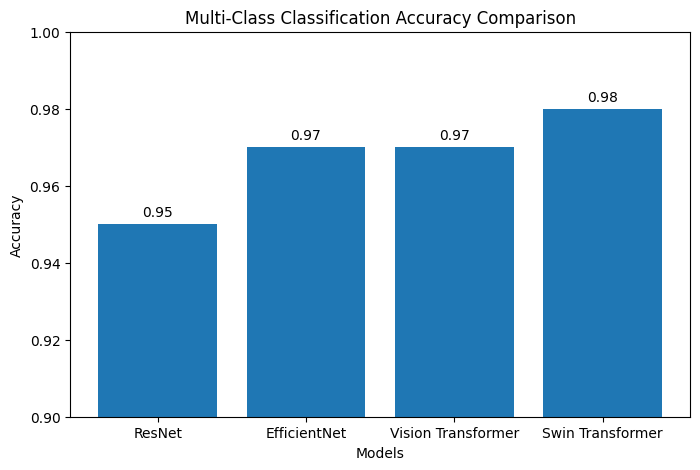

In [ ]:
import matplotlib.pyplot as plt

models = ['ResNet', 'EfficientNet', 'Vision Transformer', 'Swin Transformer']
multiclass_accuracy = [0.95, 0.97, 0.97, 0.98]

plt.figure(figsize=(8,5))
bars = plt.bar(models, multiclass_accuracy)

plt.title("Multi-Class Classification Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0.90, 1.00)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.002, f"{y:.2f}",
             ha='center')

plt.show()

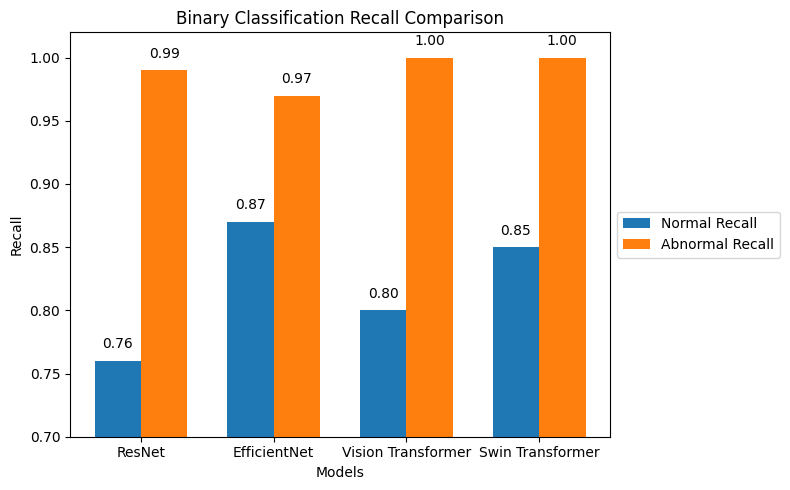

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['ResNet', 'EfficientNet', 'Vision Transformer', 'Swin Transformer']

normal_recall = [0.76, 0.87, 0.80, 0.85]
abnormal_recall = [0.99, 0.97, 1.00, 1.00]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

bars1 = plt.bar(x - width/2, normal_recall, width, label='Normal Recall')
bars2 = plt.bar(x + width/2, abnormal_recall, width, label='Abnormal Recall')

plt.xticks(x, models)
plt.ylabel("Recall")
plt.xlabel("Models")
plt.title("Binary Classification Recall Comparison")
plt.ylim(0.70,1.02)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

for bar in bars1:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.01, f"{y:.2f}", ha='center')

for bar in bars2:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.01, f"{y:.2f}", ha='center')

plt.tight_layout()
plt.show()

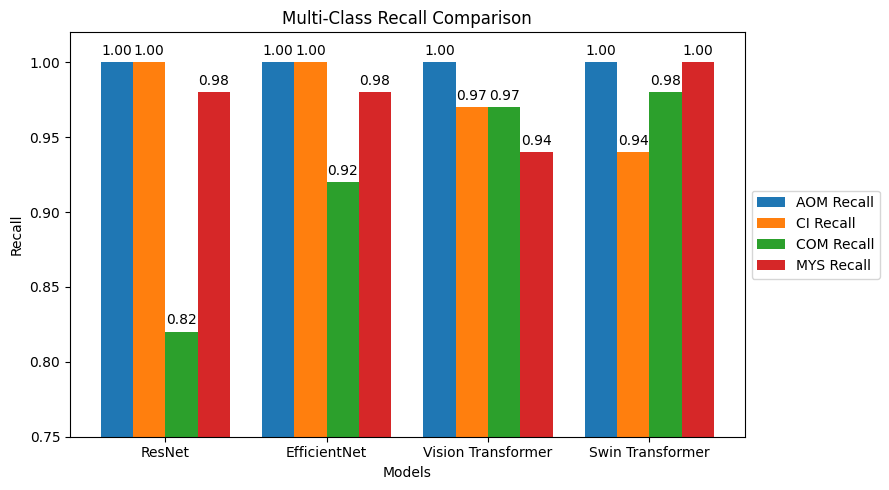

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['ResNet', 'EfficientNet', 'Vision Transformer', 'Swin Transformer']

AOM = [1.00, 1.00, 1.00, 1.00]
CI  = [1.00, 1.00, 0.97, 0.94]
COM = [0.82, 0.92, 0.97, 0.98]
MYS = [0.98, 0.98, 0.94, 1.00]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(9,5))

bars1 = plt.bar(x - 1.5*width, AOM, width, label='AOM Recall')
bars2 = plt.bar(x - 0.5*width, CI, width, label='CI Recall')
bars3 = plt.bar(x + 0.5*width, COM, width, label='COM Recall')
bars4 = plt.bar(x + 1.5*width, MYS, width, label='MYS Recall')

plt.xticks(x, models)
plt.xlabel("Models")
plt.ylabel("Recall")
plt.title("Multi-Class Recall Comparison")
plt.ylim(0.75,1.02)

plt.legend(loc='center left', bbox_to_anchor=(1,0.5))

for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        y = bar.get_height()
        plt.text(bar.get_x()+bar.get_width()/2, y+0.005, f"{y:.2f}", ha='center')

plt.tight_layout()
plt.show()